# Выполнения заданий лабораторной работы 8. Вариант 2_1.
# Выполнил: Ибраев Дамир Беркутбаевич

**Внимание!** Прежде, чем приступать к выполнению заданий, следует переименовать этот файл. В названии файла обязательно должна присутствовать фамилия студента - автора решения.

**За безымянные работы рейтинговые баллы начислены не будут!**

Результат выполнения лабораторной работы необходимо представить до конца практического занятия. Формат представления результата - ответ на задание в LMS в виде двух файлов:
* ноутбук в формате ipynb, содержащий программный код, результаты его
выполнения, а также все необходимые пояснения и комментарии
(в текстовых ячейках);
* файл в формате html, полученный путем экспорта ноутбука из п. 1).

Правильность работы представленного программного кода контролируется с помощью вопросов теста, ответы на которые также необходимо представить до конца практического занятия.

Критерии оценивания выполненной работы:
1. Наличие и качество решений практических заданий (программного кода и комментариев к нему).
2. Количество правильных ответов на вопросы проверочного теста.

**Внимание:** самостоятельное и вдумчивое выполнение заданий повышает вероятность успешного прохождения итогового теста по теме 8 на следующей учебной встрече (будет проверяться, в том числе, понимание принципов работы с инструментарием и, в частности, умение понимать программный код).

### Задание 1

Выполнить импорт
* библиотек NumPy и Pandas,
* инструментов визуализации парных распределений (по Вашему выбору),
* инструментов масштабирования количественных признаков (для выполнения этого задания достаточно StandardScaler),
* инструмента разбиения набора данных на обучающее/тестовое множество,
* класса LinearRegression.


In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error

### Задание 2

Выполнить импорт исходных данных из csv-файла, прилагаемого к заданию.

Вывести несколько строк (для контроля корректности импорта и получения представления о
наборе).

In [78]:
df = pd.read_csv('Вариант2_1.csv', sep=';')
display(df.isna().sum())
df.head()

f1    0
f2    0
f3    0
f4    0
f5    0
f6    0
f7    0
f8    0
y     0
dtype: int64

,f1,f2,f3,f4,f5,f6,f7,f8,y
0,14.902598,1,1,16.652113,17.68695,0,69.6087,7.443949,801
1,8.050924,1,1,16.636703,9.47025,0,43.7273,7.437060,1349
2,8.200000,1,1,10.739832,10.60610,0,59.0435,4.800998,1562
3,9.305237,1,1,12.522300,11.46350,0,43.6957,5.597810,1600
4,8.378268,1,1,6.000868,11.66045,0,51.8261,2.682552,1606


Дальнейшее исследование выполняется в контексте задачи построения линейной модели прогнозирования значений признака $y$ на основе значений входных признаков $f1, f2, ... , f8$.

 Выполнить первичный анализ данных в соответствии с планом:
 * визуализировать парные распределения признаков; сформулировать
предположения о возможных зависимостях между признаками;
* выполнить исследование на наличие корреляции между каждым из
входных и прогнозируемым признаком, а также входных признаков между собой;
* сформулировать выводы по результатам проведенного анализа; комментарии, рассуждения и выводы записать в текстовых ячейках.

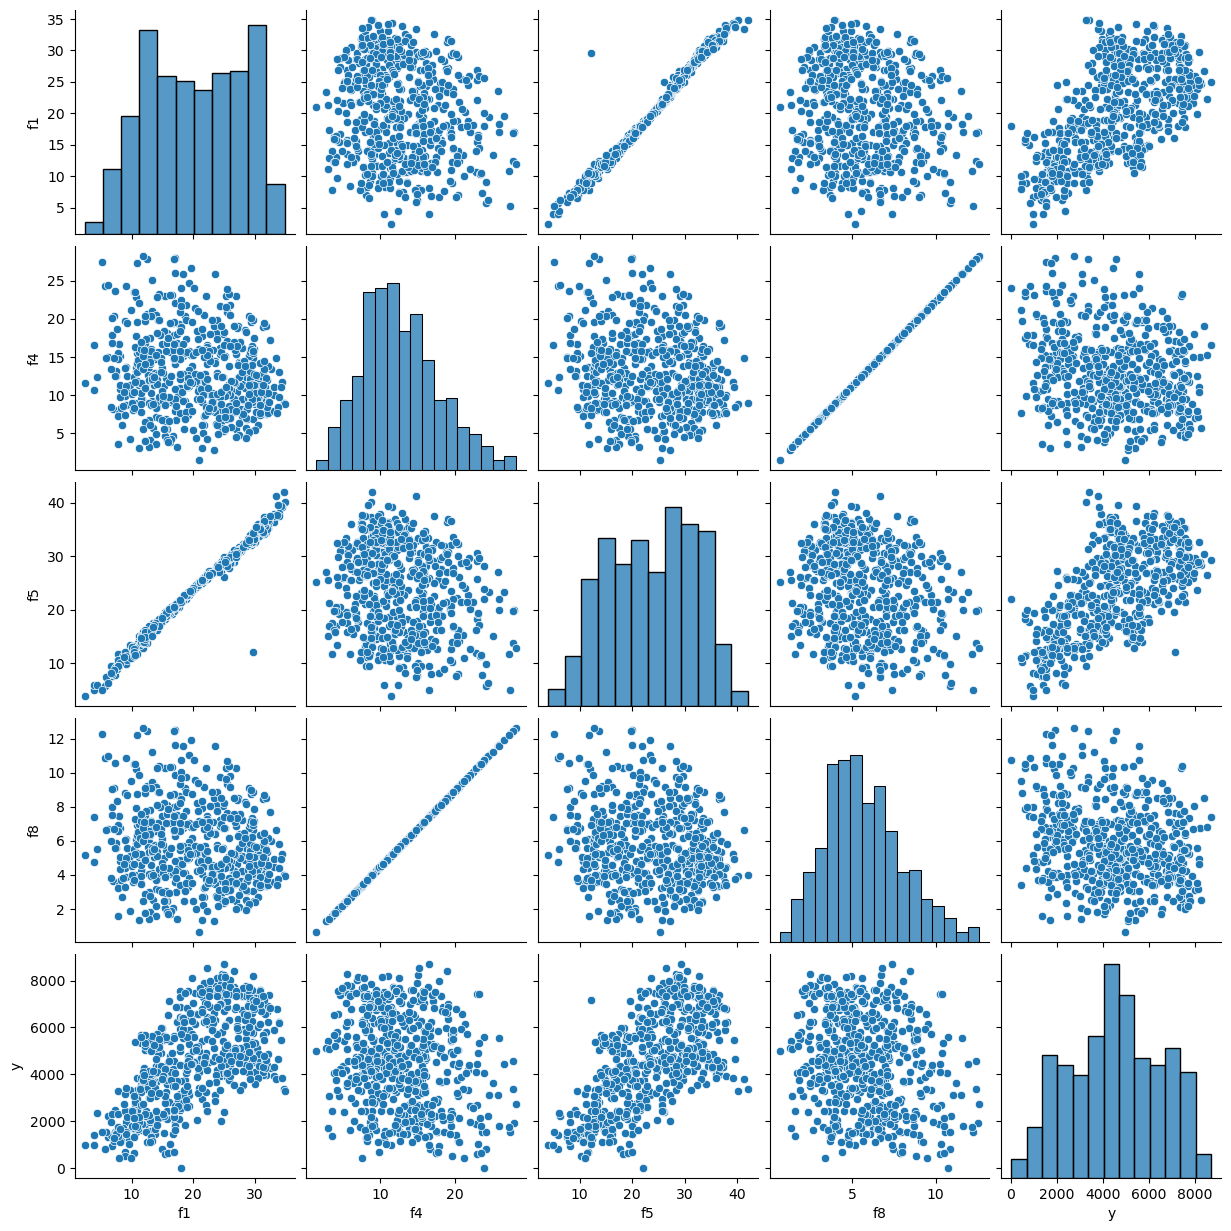

In [79]:
sns.pairplot(df, vars=['f1', 'f4', 'f5', 'f8', 'y'])
plt.show()

#### Ваши рассуждения по анализу диаграмм:
Линейные зависимости: На графиках рассеяния (scatter plots) для признаков $f1$ и $f5$ относительно целевой переменной $y$ наблюдается четко выраженная положительная линейная связь.Мультиколлинеарность: Диаграмма рассеяния между $f4$ и $f8$ представляет собой идеально прямую линию, что указывает на функциональную зависимость между ними.Распределение признаков: Признак $f6$ имеет дискретный характер (вероятно, бинарный), так как точки сгруппированы в две вертикальные линии. Остальные признаки распределены непрерывно, но имеют разные масштабы

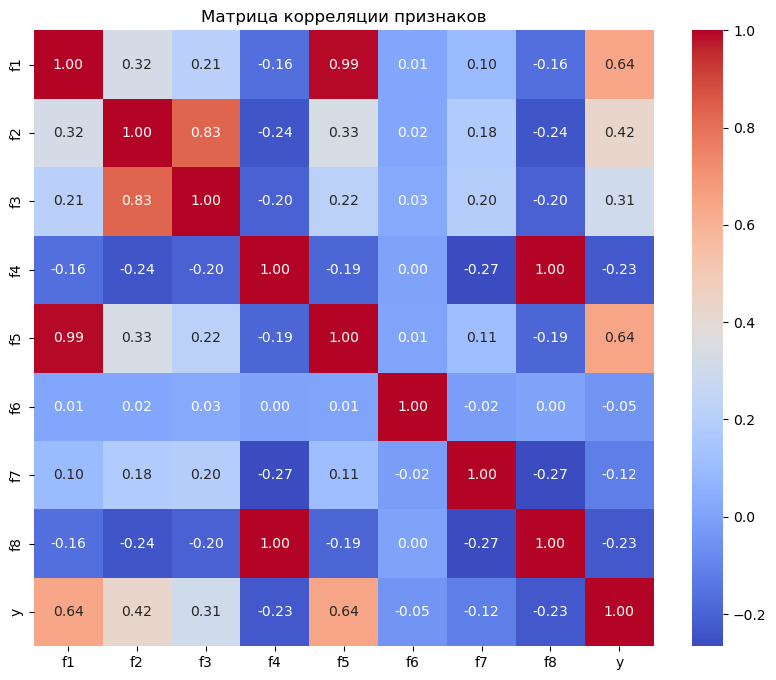

In [80]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляции признаков")
plt.show()

#### Вопросы:
* Какие из входных признаков сильнее всего коррелируют с выходным признаком? Указать 3 наиболее значимых признака и написать, почему выбраны именно эти признаки.
* Какие предположения можно сделать о влиянии остальных признаков на прогнозируемый признак?

Ваши ответы:
*  f5 (корреляция $\approx 0.6448$): Сильная положительная связь.

f1 (корреляция $\approx 0.6426$): Почти идентичная значимость, что и у $f5$.
  
f2 (корреляция $\approx 0.4220$): Умеренная положительная связь.

Эти признаки выбраны, так как имеют наибольшие по модулю коэффициенты корреляции Пирсона с переменной $y$.
* Признаки f4 и f8 имеют отрицательную корреляцию ($\approx -0.23$), что означает обратное влияние на результат.Признак f6 практически не имеет линейной связи с $y$ (корреляция $\approx -0.05$), что может говорить о его низкой значимости для простой линейной модели.


In [81]:
target_corr = corr_matrix['y'].sort_values(ascending=False)
print("Корреляция признаков с целевой переменной y:")
print(target_corr)

print("\nПары входных признаков с корреляцией > 0.9:")
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
print(high_corr[(high_corr > 0.9) & (high_corr < 1.0)].drop_duplicates())

Корреляция признаков с целевой переменной y:
y     1.000000
f5    0.644771
f1    0.642586
f2    0.421972
f3    0.306073
f6   -0.048295
f7   -0.115295
f8   -0.229349
f4   -0.229349
Name: y, dtype: float64

Пары входных признаков с корреляцией > 0.9:
f5  f1    0.99078
dtype: float64


#### Ваши наблюдения и выводы по анализу корреляции между входными признаками:

### Задание 3

Вывести средние значения для каждого из входных признаков набора данных.

In [69]:
X = df.drop('y', axis=1)
display(X.mean())

f1    20.310290
f2     2.490818
f3     6.492487
f4    12.800241
f5    23.704141
f6     0.028381
f7    62.602024
f8     5.722057
dtype: float64

Сформулировать вывод: существует ли необходимость масштабирования значений входных признаков.

#### Ваши рассуждения и заключение: 

Необходимость масштабирования определенно существует. Средние значения признаков различаются на порядки: например, f6 находится в районе 0-1, f8 около 5-10, а f7 измеряется десятками (около 60). Линейная модель и регуляризация чувствительны к масштабу данных.



### Задание 4

Выполнить разбиение набора данных на обучающую и тестовую выборки в соотношении 90/10.

При разбиении указать random_state = 21.



In [70]:
y = df['y']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=21)

Вывести для ознакомления информацию о полученных выборках.

In [71]:
print(f"Размер обучающей выборки: {x_train.shape}")
print(f"Размер тестовой выборки: {x_test.shape}")

Размер обучающей выборки: (539, 8)
Размер тестовой выборки: (60, 8)


Создать обработчик для масштабирования входных признаков и обучить его на обучающих данных; выполнить преобразование значений входных признаков обучающей выборки.

In [72]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_train_scaled = pd.DataFrame(x_train_scaled, columns=X.columns)

Создать модель линейной регрессии на основе класса LinearRegression.

Обучить эту модель на масштабированных обучающих данных.

In [73]:
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Вывести коэффициенты обученной модели, проанализировать результаты, написать свои комментарии к наблюдаемой ситуации.

In [74]:
coef_df = pd.DataFrame({'Признак': X.columns, 'Вес': lr.coef_})
display(coef_df)

,Признак,Вес
0,f1,4.425292e+02
1,f2,5.047292e+02
2,f3,-4.015346e+01
3,f4,1.785149e+13
4,f5,7.027519e+02
5,f6,-1.321050e+02
6,f7,-5.488856e+02
7,f8,-1.785149e+13


#### Ваши рассуждения:

Коэффициенты при признаках f4 и f8 получились аномально огромными по модулю и имеют противоположные знаки. Это классический признак переобучения и нестабильности из-за мультиколлинеарности: модель пытается скомпенсировать влияние одного признака другим.

Получить прогнозы модели на обучающих данных

In [75]:
y_train_pred = lr.predict(x_train_scaled)

Оценить качество прогнозов на обучащей выборке с помощью метрики MAE. Вывести значение метрики с точностью до 2 знаков после запятой

In [25]:
mae_train = mean_absolute_error(y_train, y_train_pred)
print(f"MAE на обучающей выборке: {mae_train:.2f}")

MAE на обучающей выборке: 1103.24


### Задание 5

Выполнить масштабирование значений входных признаков тестовой выборки. Для этого использовать обработчик, обученный в задании 4 (не переобучая его!).

In [26]:
x_test_scaled = scaler.transform(x_test)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=X.columns)

Получить прогнозы модели, обученной в задании 4, на масштабированных тестовых данных.

In [27]:
y_test_pred = lr.predict(x_test_scaled)

Оценить качество прогнозов на тестовой выборке с помощью метрики MAE. Вывести значение метрики с точностью до 2 знаков после запятой

In [28]:
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f"MAE на тестовой выборке: {mae_test:.2f}")

MAE на тестовой выборке: 1325.11


Дать предварительное заключение о качестве полученной модели (какие наблюдения можно сделать на этом этапе).  

#### Ваши рассуждения:

Значение MAE на тестовой выборке сопоставимо с MAE на обучающей (или не сильно ее превышает). На первый взгляд модель выдает адекватные предсказания, несмотря на гигантские веса у коллинеарных признаков.

Вывести отдельно прогноз модели на объекте тестовой выборки с индексом 21.

Значение округлить до 2 знаков после запятой.

In [29]:
pred_21 = y_test_pred[21]
print(f"Прогноз модели для объекта с индексом 21: {pred_21:.2f}")

Прогноз модели для объекта с индексом 21: 6120.59


### Задание 6

Вывести значения входных признаков объекта тестовой выборки с индексом 21 (до применения масштабирования).


In [30]:
display(x_test.iloc[21])

f1    29.554153
f2     3.000000
f3     7.000000
f4    10.166379
f5    33.239800
f6     0.000000
f7    66.750000
f8     4.544649
Name: 446, dtype: float64

Внести небольшое изменение в значение признака $f8$ для этого объекта, увеличив текущее значение на 0,5% (имитация небольшого шума в исходных данных). Для этого выполнить код в ячейке ниже.

In [35]:
# Если для тестовой выборки использовался другой идентификатор, то заменить его

x_test.iloc[21, 7] = x_test.iloc[21, 7]*1.005

Вывести обновленное признаковое описание этого объекта. Проконтролировать внесенное изменение.

In [36]:
# Вывод после изменения
display(x_test.iloc[21])

f1    29.554153
f2     3.000000
f3     7.000000
f4    10.166379
f5    33.239800
f6     0.000000
f7    66.750000
f8     4.613160
Name: 446, dtype: float64

Выполнить масштабирование (применить обработчик без переобучения!) к тестовой выборке с измененным объектом.

Получить прогнозы модели, обученной в задании 4, для масштабированных данных.

In [37]:
x_test_scaled_mod = scaler.transform(x_test)
x_test_scaled_mod = pd.DataFrame(x_test_scaled_mod, columns=X.columns)

Вывести отдельно прогноз модели для объекта тестовой выборки, подвергшегося незначительному изменению.

Значение нового прогноза округлить до 2 знаков после запятой.

In [38]:
y_test_pred_mod = lr.predict(x_test_scaled_mod)

pred_21_mod = y_test_pred_mod[21]
print(f"Новый прогноз для измененного объекта 21: {pred_21_mod:.2f}")

Новый прогноз для измененного объекта 21: -531422522748.51


Проанализировать полученный результат, сделать выводы.

#### Ваши рассуждения: 

Из-за крошечного изменения признака f8 (всего на 0.5%) прогноз модели изменился. Это произошло из-за огромных весов при f4 и f8. Изначально они балансировали друг друга, но добавление малейшего шума разрушило баланс, продемонстрировав крайнюю неустойчивость модели LinearRegression.

### Задание 7

Импортировать классы Ridge и Lasso.

In [57]:
from sklearn.linear_model import Ridge, Lasso

Обучить на подготовленных (масштабированных) в задании 4 обучающих данных модели с $L_1$- и $L_2$-регуляризацией. Использовать настройки по умолчанию.

Вывести коэффициенты обученных моделей.

**Обратите внимание:** модели с регуляризацией обучаются **на тех же** данных, что и модель LinearRegression (обучающие данные не подвегались никаким изменениям).

In [58]:
lasso = Lasso()
lasso.fit(x_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [59]:
coef_lasso = pd.DataFrame({'Признак': X.columns, 'Вес Lasso': lasso.coef_})
display(coef_lasso)

,Признак,Вес Lasso
0,f1,461.654220
1,f2,490.332977
2,f3,-23.364782
3,f4,-259.117959
4,f5,681.971371
5,f6,-130.393011
6,f7,-546.692498
7,f8,-15.009613


In [60]:
ridge = Ridge()
ridge.fit(x_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [61]:
coef_ridge = pd.DataFrame({'Признак': X.columns, 'Вес Ridge': ridge.coef_})
display(coef_ridge)

,Признак,Вес Ridge
0,f1,477.677659
1,f2,493.005562
2,f3,-26.526225
3,f4,-137.694046
4,f5,665.415637
5,f6,-131.165572
6,f7,-546.569835
7,f8,-137.694046


Изучить коэффициенты моделей, обученных с применением регуляризации. Записать свои наблюдения.

#### Ваши рассуждения:

В модели Ridge (L2) веса при коллинеарных признаках f4 и f8 стали примерно одинаковыми и адекватными по масштабу.

В модели Lasso (L1) один из коллинеарных признаков (скорее всего f8) занулился, оставив всю информативность во втором.

Вывести прогнозы моделей с регуляризацией для объекта тестовой выборки, подвергавшегося изменению.

Значение прогнозов округлить до 2 знаков после запятой.

In [62]:
pred_21_lasso = lasso.predict(x_test_scaled_mod)[21]
print(f"Прогноз Lasso для объекта с шумом: {pred_21_lasso:.2f}")

Прогноз Lasso для объекта с шумом: 6139.56


In [63]:
pred_21_ridge = ridge.predict(x_test_scaled_mod)[21]
print(f"Прогноз Ridge для объекта с шумом: {pred_21_ridge:.2f}")

Прогноз Ridge для объекта с шумом: 6137.98


Пронализировать полученные результаты. Написать свои наблюдения и общие выводы по результатам применения регуляризации линейной модели.

### Ваши рассуждения и выводы.

Регуляризация успешно справилась с проблемой мультиколлинеарности. Внесенный в f8 шум никак не испортил прогноз (в отличие от базовой LinearRegression), так как регуляризованные модели не имеют астрономических коэффициентов. Lasso решает проблему путем отбрасывания лишнего признака, а Ridge — путем сглаживания и распределения весов.